17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 73s 223ms/step - accuracy: 0.7170 - loss: 0.5274 - val_accuracy: 0.8686 - val_loss: 0.3113
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 71s 227ms/step - accuracy: 0.9007 - loss: 0.2579 - val_accuracy: 0.8756 - val_loss: 0.3032
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 69s 221ms/step - accuracy: 0.9392 - loss: 0.1659 - val_accuracy: 0.8278 - val_loss: 0.3739
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 70s 223ms/step - accuracy: 0.9501 - loss: 0.1387 - val_accuracy: 0.8664 - val_loss: 0.3596
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 222ms/step - accuracy: 0.9732 - loss: 0.0841 - val_accuracy: 0.8680 - val_loss: 0.4786
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.8545 - loss: 0.5237

Test Accuracy: 0.8565599918365479
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.88      0.86     12500
           1       0.87      0.84      0.85     12500

    accuracy    

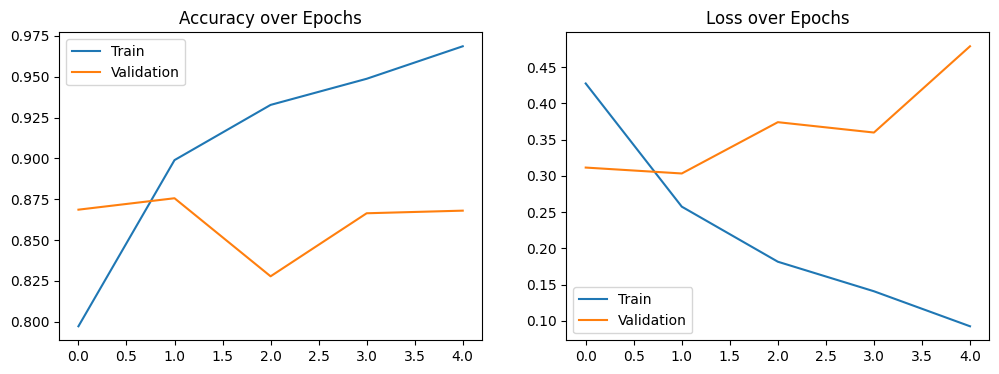


Experiment Completed Successfully ✅


In [1]:
# ============================
# EXPERIMENT 9
# RNN / LSTM for Text Classification
# Dataset: IMDB Movie Reviews
# ============================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import classification_report

# ----------------------------
# 1. Load Dataset
# ----------------------------
max_words = 10000   # Vocabulary size
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=max_words)

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

# ----------------------------
# 2. Preprocessing (Padding)
# ----------------------------
max_length = 200

x_train = pad_sequences(x_train, maxlen=max_length)
x_test = pad_sequences(x_test, maxlen=max_length)

# ----------------------------
# 3. Build LSTM Model
# ----------------------------

model = keras.Sequential([
    layers.Embedding(input_dim=max_words, output_dim=128, input_length=max_length),
    layers.LSTM(64),
    layers.Dense(1, activation='sigmoid')
])

# ----------------------------
# 4. Compile Model
# ----------------------------

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ----------------------------
# 5. Train Model
# ----------------------------

history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# ----------------------------
# 6. Evaluate Model
# ----------------------------

test_loss, test_acc = model.evaluate(x_test, y_test)
print("\nTest Accuracy:", test_acc)

y_pred = (model.predict(x_test) > 0.5).astype("int32")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ----------------------------
# 7. Accuracy & Loss Plot
# ----------------------------

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy over Epochs")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss over Epochs")
plt.legend()

plt.show()

print("\nExperiment Completed Successfully ✅")